In [16]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

In [17]:
from langchain_groq import ChatGroq

llm = ChatGroq(model_name = "llama-3.1-8b-instant" ,api_key = groq_api_key)

In [18]:
from typing_extensions import TypedDict
import operator
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage, SystemMessage
from typing import Annotated,List,Literal

class State(TypedDict):
    joke:str
    topic:str
    feedback:str
    funny_or_not:str

In [19]:
# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade:Literal["funny","not funny"] = Field(description="Decide if joke is funny or not")
    feedback:str = Field(description="if the joke is not funny, provide feedback on how to imporove it")

# Augment the llm with schema for structured output
evaluator = llm.with_structured_output(Feedback)

In [20]:
def llm_call_generator(state:State):
    """LLM generated a joke"""
    if state.get("feedback") == None:
        msg = llm.invoke(f"Write a joke about {state["topic"]}")
    else:
        msg = llm.invoke(f"Write a joke about {state["topic"]} but take into account the feedback: {state["feedback"]}")
    return {"joke":msg.content}

In [21]:
def llm_call_evaluator(state:State):
    """LLm evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state["joke"]}")
    return{"funny_or_not":grade.grade,"feedback":grade.feedback}

In [22]:
def take_decision(state:State):
    if state["funny_or_not"] == "not funny":
        return "Rejected + feedback"
    else:
        return "Accepted"

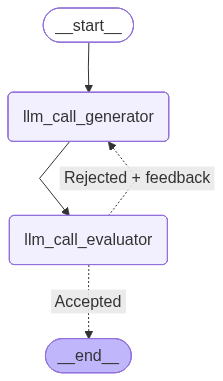

In [23]:
from langgraph.graph import StateGraph, START,END
from IPython.display import display,Image

graph = StateGraph(State)

# adding the nodes
graph.add_node("llm_call_generator",llm_call_generator)
graph.add_node("llm_call_evaluator",llm_call_evaluator)

# add the edges
graph.add_edge(START,"llm_call_generator")
graph.add_edge("llm_call_generator","llm_call_evaluator")
graph.add_conditional_edges("llm_call_evaluator",take_decision,{"Rejected + feedback" : "llm_call_generator","Accepted":END})

graph_builder = graph.compile()
visualize_graph = graph_builder.get_graph().draw_mermaid_png()
display(Image(visualize_graph))



In [29]:
from pprint import pprint
messages = graph_builder.invoke({"topic":"Engineer"})
print(messages["joke"])

Why did the engineer cross the road?

Because it was a bridge to a better solution.
